<a href="https://colab.research.google.com/github/Sneha17A/ML_Projects/blob/main/Learning_CNN_for_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network


In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [3]:
(x_train,y_train),(x_test,y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
Lables = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

In [22]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict['loss']
  val_loss_values = history_dict["val_loss"]
  epochs = range(1,len(loss_values)+1)
  plt.plot(epochs,loss_values,"bo",label="Training Loss")
  plt.plot(epochs,val_loss_values,"r",label="Validation Loss")
  plt.title("Training and Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [5]:
def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict['accuracy']
  val_acc = history_dict["val_accuracy"]
  epochs = range(1,len(acc)+1)
  plt.plot(epochs,acc,"bo",label="Training Accuracy")
  plt.plot(epochs,val_acc,"r",label="Validation Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

# A Convolutional Neural Network

Steps to follow

*   Data prep
*   Define model
*   Set Optimization Parameters
*   Train model
*   Evaluate model








**Data Prep**

In [6]:
x_train = x_train/255.0
x_test = x_test/255.0

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
#color images - so adding another dimension, 28*28*1
x_train = np.expand_dims(x_train,-1)
x_test = np.expand_dims(x_test,-1)

In [10]:
x_train.shape

(60000, 28, 28, 1)

**Define Model**

*Convolutional Neural Network*

In [11]:
input = keras.Input(shape = x_train.shape[1:])
#1st convolution block
x = keras.layers.Conv2D(filters=32                #no of filters
                        ,kernel_size=(2,2)        #the shape of each filter
                        ,activation="relu"        #relu activation
                        ,name = "Conv_1")(input)
x = keras.layers.MaxPool2D()(x)
#2nd convolution block
x = keras.layers.Conv2D(filters=32
                        ,kernel_size=(2,2)
                        ,activation="relu"
                        ,name = "Conv_2")(x)
x = keras.layers.MaxPool2D()(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256,activation="relu")(x)
output = keras.layers.Dense(10,activation="softmax")(x)
model = keras.Model(inputs=input,outputs=output)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,026 (1.15 MB)

 Trainable params: 302,026 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

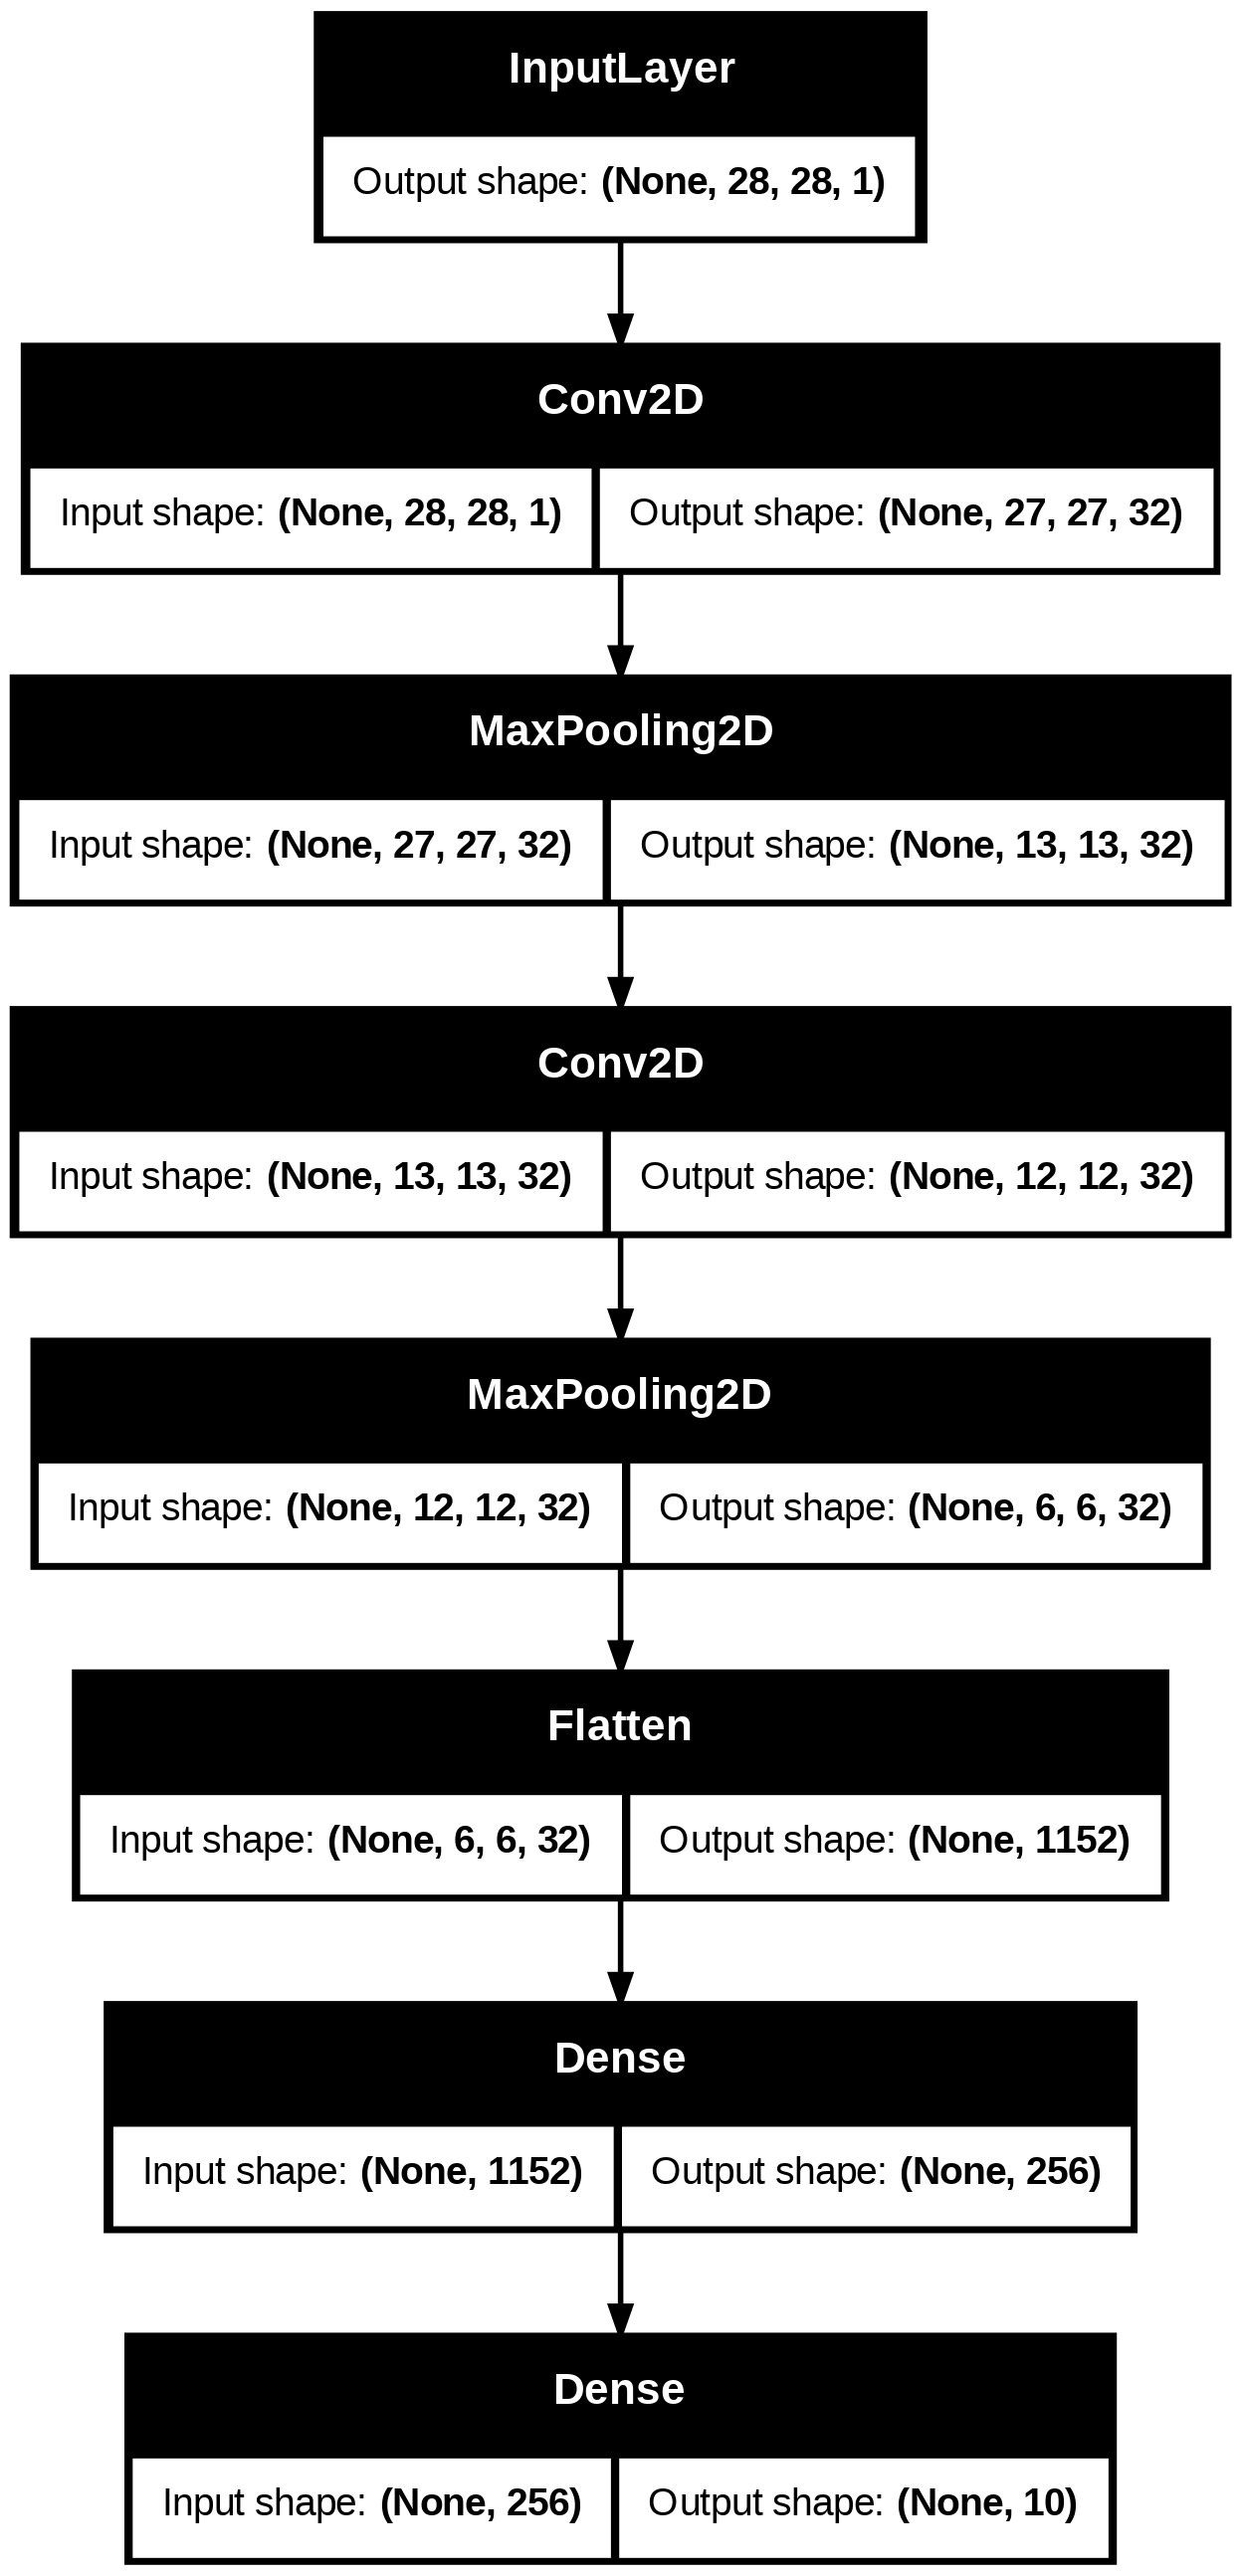

In [13]:
keras.utils.plot_model(model,show_shapes=True)

**Set Optimization Parameters**

In [14]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer = "adam",
              metrics = ['accuracy'])

**Train the model**

In [15]:
history = model.fit(x_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.8152 - loss: 0.5090 - val_accuracy: 0.8706 - val_loss: 0.3706
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.8780 - loss: 0.3396 - val_accuracy: 0.8871 - val_loss: 0.3100
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.8946 - loss: 0.2900 - val_accuracy: 0.8964 - val_loss: 0.2808
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9043 - loss: 0.2578 - val_accuracy: 0.9010 - val_loss: 0.2648
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.9141 - loss: 0.2330 - val_accuracy: 0.9047 - val_loss: 0.2577
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9224 - loss: 0.2115 - val_accuracy: 0.9064 - val_loss: 0.2581
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.9289 - loss: 0.1920 - val_accuracy: 0.9068 - val_loss: 0.2594
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.9361 - loss: 0.1738 - 

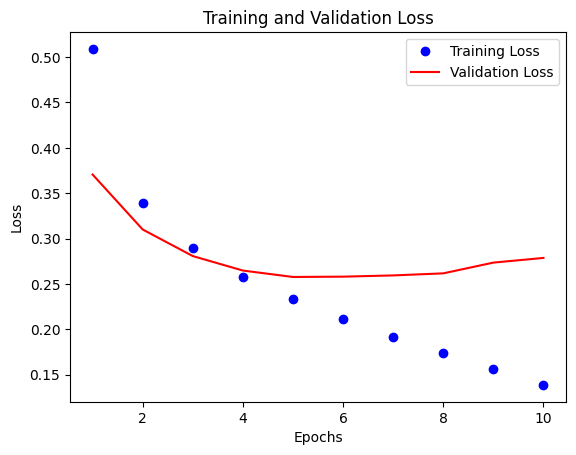

In [23]:
plot_loss_curves(history)

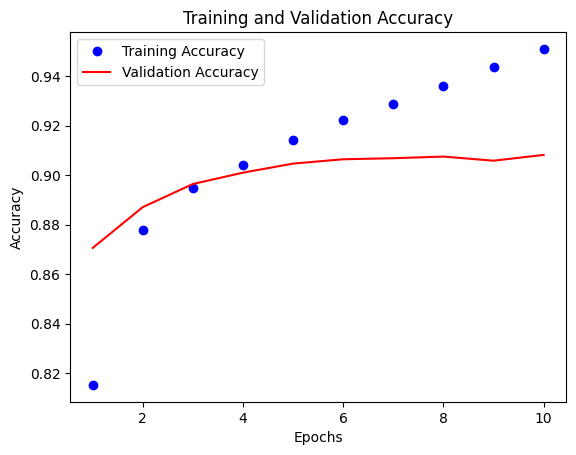

In [24]:
plot_acc_curves(history)

# Evaluate the Model

In [25]:
score = model.evaluate(x_test,y_test)
print("Test accuracy:",score[1])
#print("Test loss")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8984 - loss: 0.2905
Test accuracy: 0.8984000086784363
